In [5]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import os

from grid_simulation import get_rgb_map
from cuda_square_simulation import SquareSimulation

In [8]:
def get_results_imgs(simulation, iterations=50,  type1 = 'giving', type2 = 'attacking', type3 = 'random', save_dir=None):

    pop1_size = []
    pop2_size = []
    pop3_size = []

    for i in range(iterations):
        action_grid = simulation.configurable_actions_grid(type1=type1, type2=type2, type3=type3)
        simulation.step(action_grid)

        pop1_size.append(simulation.grid[:,0].sum(dim=(1,2)).mean(dim=0))
        pop2_size.append(simulation.grid[:,1].sum(dim=(1,2)).mean(dim=0))
        pop3_size.append(simulation.grid[:,2].sum(dim=(1,2)).mean(dim=0))

    # Get the final population distribution
    plt.figure()
    
    legend_elements = [
        Patch(facecolor='red', edgecolor='r', label=f'Type 1 : {type1}'),
        Patch(facecolor='blue', edgecolor='b', label=f'Type 2 : {type2}'),
        Patch(facecolor='green', edgecolor='g', label=f'Type 3 : {type3}'),
    ]   
    
    rgb_map = get_rgb_map(simulation, plt)
    plt.imshow(rgb_map)
    #plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.5, 1.))  
    plt.axis('off')
    plt.title('Final population distribution')
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'final_population_distribution.pdf'), bbox_inches='tight')

    plt.show()

    results = []
    results.append(pop1_size[-1])
    results.append(pop2_size[-1])
    results.append(pop3_size[-1])

    fitness_total = pop1_size[-1] + pop2_size[-1] + pop3_size[-1]

    results.append(pop1_size[-1] / fitness_total * 100)
    results.append(pop2_size[-1] / fitness_total * 100)
    results.append(pop3_size[-1] / fitness_total * 100)

    # get the final population sizes
    print('Final population fitness:')
    print(f'Population 1: {type1} - {pop1_size[-1]}')
    print(f'Population 2: {type2} - {pop2_size[-1]}')
    print(f'Population 3: {type3} - {pop3_size[-1]}')
    
    print(f'Total fitness: {fitness_total}')

    print('Final population %\'s fitness:')
    print(f'Population 1: {type1} - {pop1_size[-1] / fitness_total * 100:.2f}%')
    print(f'Population 2: {type2} - {pop2_size[-1] / fitness_total * 100:.2f}%')
    print(f'Population 3: {type3} - {pop3_size[-1] / fitness_total * 100:.2f}%')

    #
    plt.figure()
    plt.plot(np.arange(iterations), pop1_size, label=f'Population 1 : {type1}', color='red')
    plt.plot(np.arange(iterations), pop2_size, '--', label=f'Population 2 : {type2}', color='blue')
    plt.plot(np.arange(iterations), pop3_size, label=f'Population 3 : {type3}', color='green')
    plt.xlabel('Iterations')
    plt.ylabel('Population Size')
    plt.title('Population Size Over Time')
    plt.legend()
    if save_dir is not None:
        plt.savefig(os.path.join(save_dir, 'population_size_over_time.pdf'), bbox_inches='tight')
    plt.show()

    return results

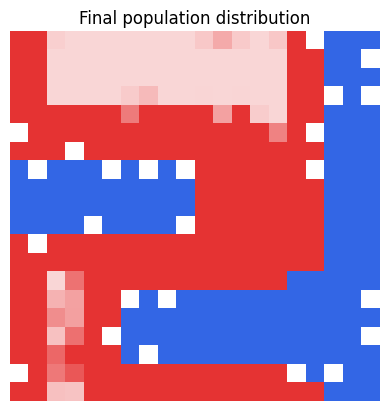

Final population fitness:
Population 1: giving - 25538914.0
Population 2: attacking - 23615690.0
Population 3: random - 0.0006148859392851591
Total fitness: 49154604.0
Final population %'s fitness:
Population 1: giving - 51.96%
Population 2: attacking - 48.04%
Population 3: random - 0.00%


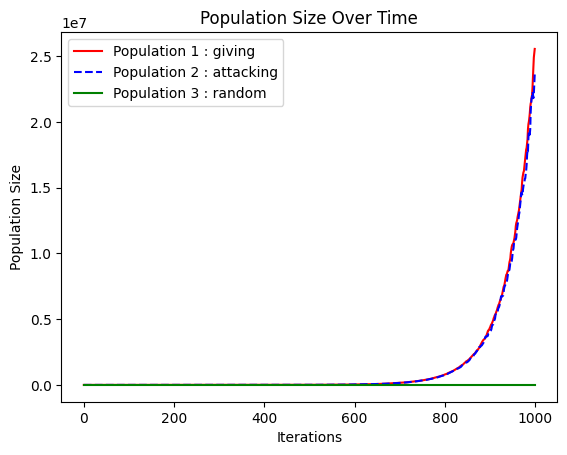

[tensor(25538914.),
 tensor(23615690.),
 tensor(0.0006),
 tensor(51.9563),
 tensor(48.0437),
 tensor(1.2509e-09)]

In [9]:
# if save_dir is None, the images will not be saved

parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
SAVE_DIR = os.path.join(parent_dir, 'simulation_imgs')
#SAVE_DIR = None

# Number of iterations 
iterations = 1000

# Simulation parameters
nb_batches = 100
rows, cols = 20, 20
populations = {
    "red": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "blue": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
    "green": {"p": 0.2, "mean_v": 1.0, "std_v": 0.1},
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Create the simulation "attack vs random"
simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
                                populations=populations, device=device)
simulation.reset()

get_results_imgs(simulation, iterations=iterations, save_dir=SAVE_DIR)

# # Create the simulation "giving vs random"
# simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
#                                 populations=populations, device=device)
# simulation.reset()
# get_results_imgs(simulation, iterations=iterations, type1='giving', type2='random', save_dir=SAVE_DIR)

# # Create the simulation "complete vs random"
# simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
#                                 populations=populations, device=device)
# simulation.reset()
# get_results_imgs(simulation, iterations=iterations, type1='complete', type2='random', save_dir=SAVE_DIR)

# # Create the simulation "giving vs attacking vs complete"
# simulation = SquareSimulation(nb_batch=nb_batches, rows=rows, cols=cols,
#                                 populations=populations, device=device)
# simulation.reset()
# get_results_imgs(simulation, iterations=iterations, type1='giving', type2='attacking', type3='random', save_dir=SAVE_DIR)


